# D4 — Dispatch économique dans un réseau électrique

> **Programmation par Contraintes — EPITA SCIA 2026**
> *Martin Couturier · Arthur Philippe · Xavier Ghostine*

---

## Objectif du projet

Ce notebook montre comment modéliser et résoudre le **dispatch économique** d'un réseau électrique à l'aide du solveur **CP-SAT** (Google OR-Tools).

Le dispatch économique répond à une question simple :
*comment répartir la production entre les centrales pour satisfaire la demande au coût le plus bas possible, sans surcharger les lignes ?*

On part d'un cas minimaliste (3 bus, 3 générateurs) et on monte progressivement en complexité jusqu'à un modèle stochastique sur 24 heures avec énergies renouvelables.

---

## Plan du notebook

| # | Section | Ce qu'on y fait |
|---|---------|-----------------|
| 1 | Dispatch économique — réseau 3 bus | Premier modèle CP-SAT, lecture des résultats |
| 2 | Instance 6 bus congestionnée | Pourquoi les contraintes de transport changent tout |
| 3 | IEEE 14-bus | Instance standard, performance du solveur |
| 4 | Unit Commitment 24 h | Planification journalière, démarrages/arrêts |
| 5 | Scénarios renouvelables | Modélisation de l'incertitude solaire/éolienne |
| 6 | UC stochastique | Décisions robustes face aux scénarios |
| 7 | Analyse VSS | Combien coûte d'ignorer l'incertitude ? |
| 8 | Benchmark de scalabilité | Temps de résolution selon la taille du réseau |
| 9 | Extensions possibles | Pistes pour aller plus loin |

---

📖 Modèle mathématique complet : [`README.md`](../README.md)
📁 Description de chaque fichier : [`DOCUMENTATION.md`](../DOCUMENTATION.md)

In [ ]:
# Make src importable regardless of CWD
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 110

from src import (
    Generator, Bus, Line, PowerNetwork,
    three_bus_toy, six_bus_congested, ieee14,
    solve_economic_dispatch, solve_unit_commitment, solve_stochastic_uc,
    solar_profile, wind_profile, sample_scenarios,
)
from src.instance import add_renewables
from src.unit_commitment import daily_load_profile
from src import visualization as viz
print("Package loaded.")

Package loaded.


## 1 · Dispatch économique — réseau jouet 3 bus

On commence par le cas le plus simple pour comprendre ce que fait le modèle.

**Le réseau :**
- **Bus 0** — centrale de production (pas de consommation)
- **Bus 1** — ville avec 120 MW de charge
- **Bus 2** — ville avec 180 MW de charge

**Les trois générateurs thermiques :**

| Générateur | Bus | P_min / P_max | Coût ($/h) | Rôle |
|------------|----:|:---:|---|---|
| G1-base    | 0 | 50 / 250 MW | 300 + 18·P + 0.004·P² | Baseload bon marché |
| G2-mid     | 1 | 20 / 120 MW | 200 + 25·P + 0.008·P² | Mi-charge |
| G3-peaker  | 2 | 10 / 80 MW  | 100 + 40·P + 0.015·P² | Pointe, très cher |

Le coût de chaque centrale est **quadratique** : il augmente plus vite que linéairement avec la puissance produite.
CP-SAT ne sait pas optimiser des fonctions quadratiques directement — on les approche par **6 droites tangentes** (linéarisation par morceaux).

**Ce que le modèle minimise :**

```
min  somme_g ( a_g + b_g * P_g + c_g * P_g^2 )

soumis à :
  - équilibre offre/demande sur chaque bus
  - capacité des lignes de transport
  - P_min_g <= P_g <= P_max_g  pour chaque générateur allumé
  - réserve tournante (spinning reserve) >= 10% de la charge totale
```

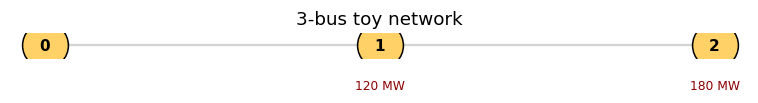

In [ ]:
net = three_bus_toy(peak_load=300)

fig = viz.plot_network(net, layout={0:(-1.5, 0), 1:(0, 0), 2:(1.5, 0)},
                       title='3-bus toy network')
plt.show()

In [ ]:
sol = solve_economic_dispatch(net, time_limit_s=10)
print(sol.report())

Status      : OPTIMAL
Total cost  : $6,519.20/h
Wall time   : 0.04 s

Generator      Bus    P (MW)    P_min    P_max  on
G1-base          0    250.00       50      250   1
G2-mid           1     50.00       20      120   1
G3-peaker        2      0.00       10       80   0

Line flows (positive = from -> to):
  L0  B0->B1   +250.00 / ±280 MW   
  L1  B1->B2   +180.00 / ±220 MW   


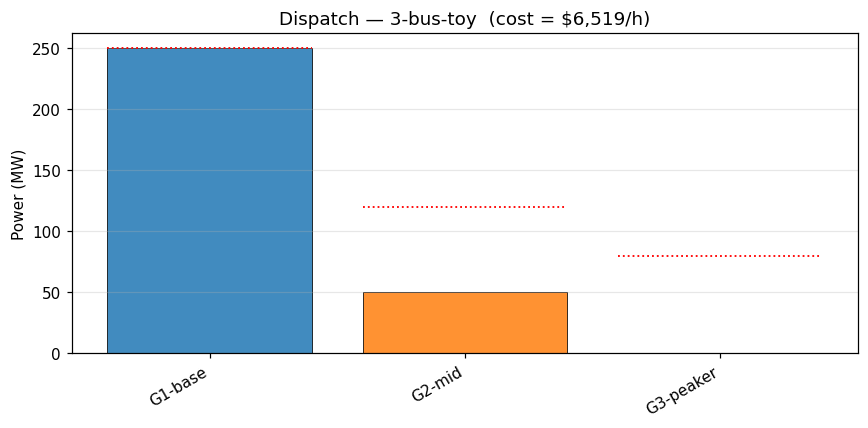

In [ ]:
fig = viz.plot_single_period(sol)
plt.show()

**Lecture du résultat.**

- **G1** (le moins cher) absorbe l'essentiel de la charge et tourne à pleine puissance.
- **G2** reste allumé à faible puissance à cause de la **réserve tournante** : les centrales en marche doivent conserver 30 MW de marge (10 % de 300 MW) pour répondre à un pic imprévu.
- **G3** (le plus cher) reste éteint — inutile tant que G1 et G2 couvrent la demande.

> La réserve tournante explique pourquoi on ne choisit pas toujours uniquement le générateur le moins cher.

## 2 · Réseau 6 bus — quand les lignes de transport sont saturées

Sur un réseau sans contraintes de transport, le dispatch optimal suit l'**ordre de mérite** : on active d'abord le générateur le moins cher, puis le suivant, etc.

Dès qu'une **ligne est saturée**, cette règle ne tient plus. CP-SAT est précisément conçu pour gérer ces situations.

**Topologie :**
- Charbon bon marché au Nord (Bus 0)
- Gaz mi-prix au centre (Bus 2)
- Centrales de pointe chères au Sud (Bus 4 et 5)
- Un goulot d'étranglement : la liaison B2→B3 est limitée à **70 MW** (ligne `L3`)

On va voir que le générateur nord ne peut pas exporter autant qu'il le voudrait — et que les centrales du Sud sont obligées de produire plus pour compenser.

In [ ]:
net6 = six_bus_congested()
sol6 = solve_economic_dispatch(net6, time_limit_s=10)
print(sol6.report())
print(f'\nMerit-order baseline (ignoring lines): ${sol6.merit_order_cost():,.2f}/h')
print(f'Transmission premium:                  ${sol6.total_cost - sol6.merit_order_cost():,.2f}/h '
      f'(+{100*(sol6.total_cost/sol6.merit_order_cost()-1):.1f}%)')

Status      : OPTIMAL
Total cost  : $11,713.67/h
Wall time   : 0.00 s

Generator      Bus    P (MW)    P_min    P_max  on
G-coal-N         0    200.00       80      300   1
G-gas-M          2      0.00       30      150   0
G-peak-S         4     90.00       10       90   1
G-peak-X         5     50.00       10       60   1

Line flows (positive = from -> to):
  L0  B0->B1   +150.00 / ±150 MW   ***
  L1  B0->B2    +50.00 / ±90 MW   
  L2  B1->B2    +60.00 / ±80 MW   
  L3  B2->B3    +70.00 / ±70 MW   ***
  L4  B3->B4    +80.00 / ±120 MW   
  L5  B3->B5    -60.00 / ±60 MW   ***
  L6  B4->B5    +30.00 / ±60 MW   

Merit-order baseline (ignoring lines): $6,251.20/h
Transmission premium:                  $5,462.47/h (+87.4%)


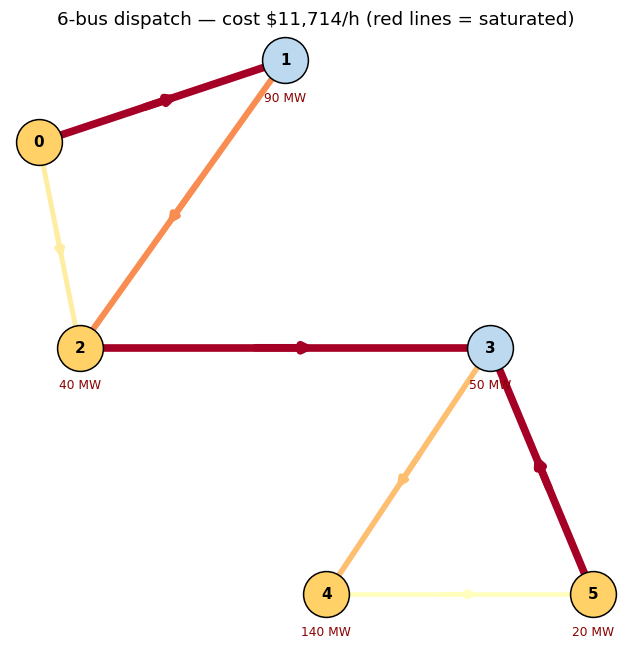

In [ ]:
layout6 = {0:(-1.2,  1.0), 1:( 0.0,  1.4), 2:(-1.0, 0.0),
           3:( 1.0,  0.0), 4:( 0.2, -1.2), 5:( 1.5, -1.2)}
fig = viz.plot_network(net6, flows=sol6.flows, layout=layout6,
                       title=f'6-bus dispatch — cost ${sol6.total_cost:,.0f}/h '
                              '(red lines = saturated)')
plt.show()

**Ce que montre la congestion.**

Les lignes `L0` (B0→B1), `L3` (B2→B3) et `L5` (B3→B5) sont marquées `***` : elles atteignent leur capacité maximale.

Conséquence : le charbon du Nord est bridé bien en dessous de sa capacité maximale, et les centrales coûteuses du Sud doivent compenser.

| Coût | Montant |
|------|---------|
| Dispatch optimal avec lignes | ~11 714 $/h |
| Dispatch sans contraintes de transport (ordre de mérite pur) | ~6 251 $/h |
| **Prime de congestion** | **+87 %** |

> C'est la valeur ajoutée de CP-SAT par rapport à une règle naïve : il respecte les limites physiques du réseau.

## 3 · IEEE 14-bus — instance de référence

Le **système IEEE 14-bus** est un cas test standardisé, utilisé dans la littérature académique depuis les années 1960. Il modélise une portion du réseau électrique Eastern Interconnection (États-Unis).

**Caractéristiques :**
- 14 nœuds (bus)
- 20 branches de transport
- 5 générateurs
- ~260 MW de charge totale répartie sur le réseau

C'est une instance suffisamment réaliste pour être représentative, mais encore très rapide à résoudre (< 1 seconde avec CP-SAT).
Elle sert de **référence de comparaison** pour les algorithmes de dispatch dans la littérature.

In [ ]:
net14 = ieee14()
sol14 = solve_economic_dispatch(net14, time_limit_s=10)
print(sol14.report())

Status      : OPTIMAL
Total cost  : $5,911.96/h
Wall time   : 0.29 s

Generator      Bus    P (MW)    P_min    P_max  on
G1               0    261.00       50      332   1
G2               1      0.00       20      140   0
G3               2      0.00       20      100   0
G6               5      0.00       10       80   0
G8               7      0.00       10       60   0

Line flows (positive = from -> to):
  L0  B0->B1   +101.00 / ±160 MW   
  L1  B0->B4   +160.00 / ±160 MW   ***
  L2  B1->B2   +159.00 / ±160 MW   ***
  L3  B1->B3    -56.00 / ±100 MW   
  L4  B1->B4    -24.00 / ±80 MW   
  L5  B2->B3    +65.00 / ±100 MW   
  L6  B3->B4    -81.00 / ±100 MW   
  L7  B4->B5    +47.00 / ±80 MW   
  L8  B5->B10    +16.00 / ±50 MW   
  L9  B5->B11     +6.00 / ±50 MW   
  L10  B5->B12    +14.00 / ±60 MW   
  L11  B3->B6     +0.00 / ±80 MW   
  L12  B3->B8    +42.00 / ±80 MW   
  L13  B6->B7     +0.00 / ±60 MW   
  L14  B6->B8     +0.00 / ±60 MW   
  L15  B8->B9     -3.00 / ±50 MW   
  L16 

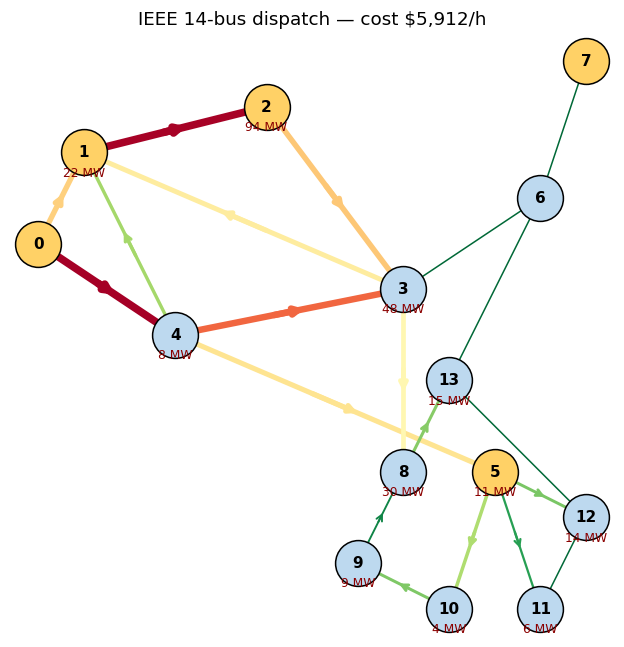

In [ ]:
# Bus layout taken from the canonical IEEE 14-bus diagram
layout14 = {
    0:(-2.5,  2.5), 1:(-2.0,  3.5), 2:( 0.0,  4.0), 3:( 1.5,  2.0),
    4:(-1.0,  1.5), 5:( 2.5,  0.0), 6:( 3.0,  3.0), 7:( 3.5,  4.5),
    8:( 1.5,  0.0), 9:( 1.0, -1.0), 10:(2.0, -1.5), 11:(3.0, -1.5),
    12:(3.5, -0.5), 13:(2.0,  1.0),
}
fig = viz.plot_network(net14, flows=sol14.flows, layout=layout14,
                       title=f'IEEE 14-bus dispatch — cost ${sol14.total_cost:,.0f}/h')
plt.show()

## 4 · Unit Commitment — planification sur 24 heures

Optimiser un seul instant à la fois ignore les **contraintes temporelles** des centrales :

- Une centrale démarrée doit rester allumée un certain nombre d'heures (**temps minimum ON**)
- Une centrale arrêtée ne peut pas redémarrer immédiatement (**temps minimum OFF**)
- La puissance ne peut pas varier brutalement d'une heure à l'autre (**limites de rampe**)
- Démarrer une centrale a un coût fixe (montée en température, usure)

L'**Unit Commitment (UC)** résout simultanément les 24 heures du lendemain, en décidant pour chaque centrale et chaque heure si elle est ON ou OFF.

**Variables du modèle CP-SAT :**

| Variable | Type | Signification |
|----------|------|---------------|
| `u[g,t]` | binaire | Générateur `g` allumé (1) ou éteint (0) à l'heure `t` |
| `su[g,t]` | binaire | Démarrage de `g` à l'heure `t` (transition 0→1) |
| `sd[g,t]` | binaire | Arrêt de `g` à l'heure `t` (transition 1→0) |
| `p[g,t]` | entier | Puissance produite (MW) |

**La courbe de charge simulée** représente un jour typique : creux vers 4h du matin, pic de consommation à 19h le soir.

In [ ]:
net  = three_bus_toy(peak_load=300)
load = daily_load_profile(net, H=24, peak_factor=1.3, off_peak_factor=0.55,
                          peak_hour=19)

uc = solve_unit_commitment(net, load, time_limit_s=40)
print(uc.report())

Status       : FEASIBLE
Horizon      : 24 h
Total cost   : $148,424.76
  fuel       : $147,874.76
  start-ups  : $550.00
  shut-downs : $0.00
Optimality   : gap = 13.48 %
Wall time    : 40.45 s

Schedule (1 = ON):
Gen            0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18  19  20  21  22  23
  G1-base      1   1   1   1   1   1   1   1   1   1   1   1   1   1   1   1   1   1   1   1   1   1   1   1
  G2-mid       1   1   1   0   0   0   0   0   0   0   0   0   1   1   1   1   1   1   1   1   1   1   1   1
  G3-peaker    1   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   1   1   1   1   1   1   1   0


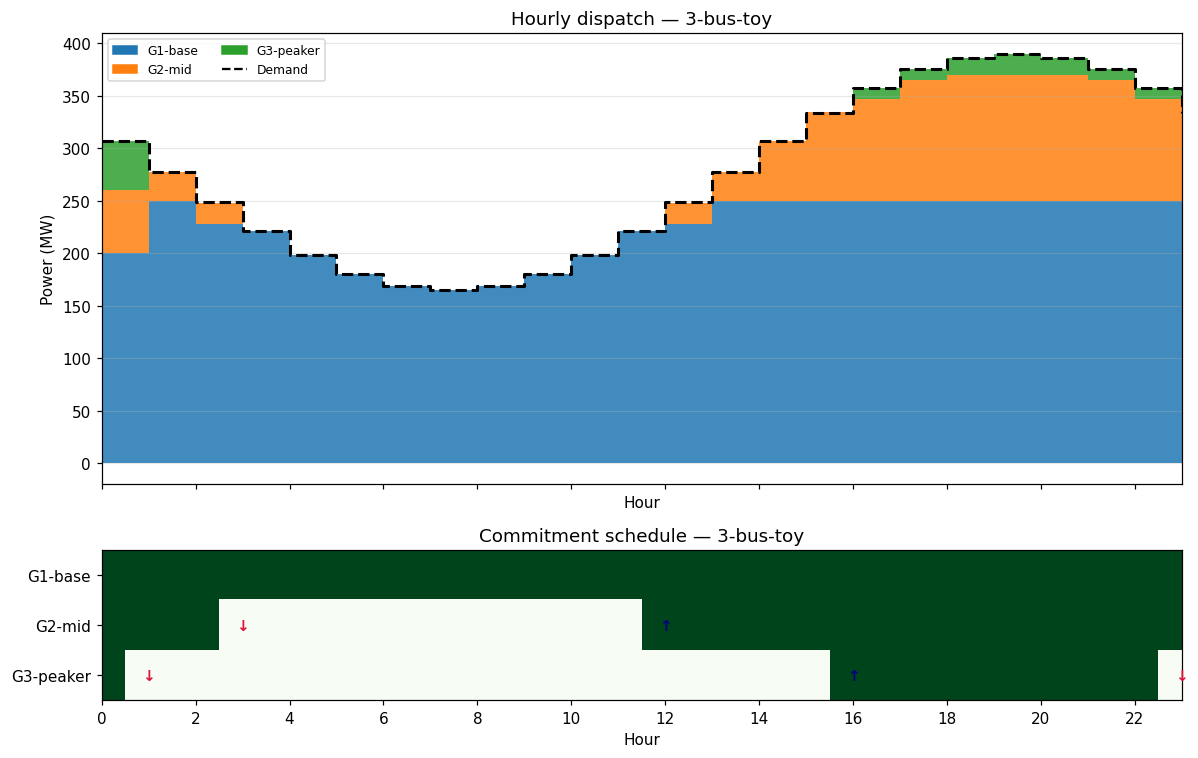

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True,
                         gridspec_kw=dict(height_ratios=[3, 1]))
viz.plot_dispatch_stack(uc, ax=axes[0])
viz.plot_schedule(uc, ax=axes[1])
plt.tight_layout(); plt.show()

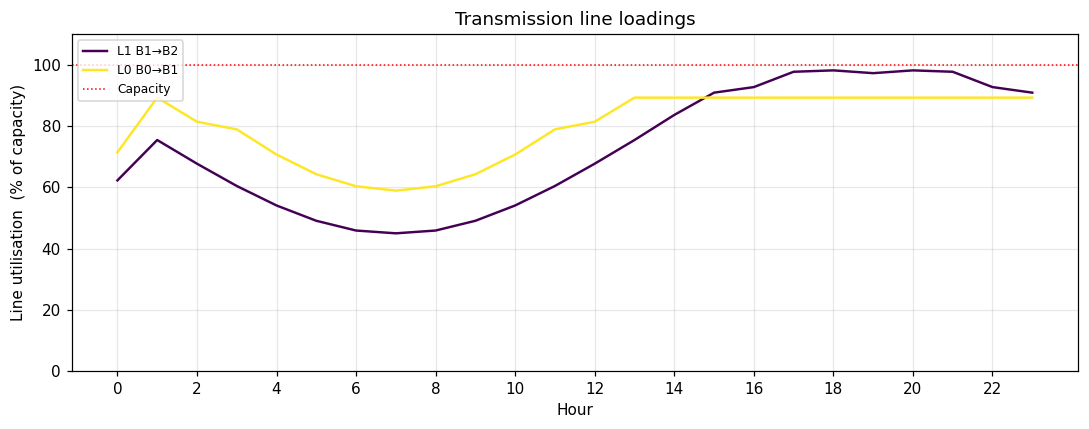

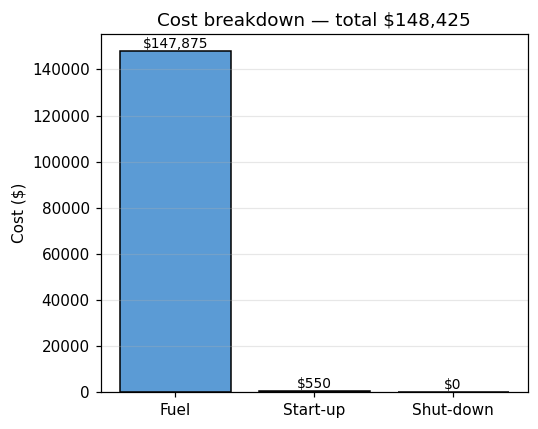

In [ ]:
fig = viz.plot_line_loadings(uc, top_k=4)
plt.show()
fig = viz.plot_cost_breakdown(uc)
plt.show()

**Lecture du planning.**

- **G1** (baseload bon marché) tourne toute la journée — ses coûts de démarrage/arrêt et son utilité permanente ne justifient pas de l'éteindre.
- **G2** s'arrête pendant le creux de la nuit (heures 3–12), puis redémarre pour couvrir l'après-midi et le soir.
- **G3** (centrale de pointe) ne s'allume que pendant le pic du soir. Un seul démarrage coûte 150$, mais rester dans la norme de réserve coûterait plus cher sans lui.

**Les deux graphiques :**
- *En haut* — production empilée par centrale (aires colorées) + courbe de charge (pointillés noirs)
- *En bas* — calendrier ON/OFF sous forme de heatmap (blanc = OFF, coloré = ON, flèches = transitions)

## 5 · Scénarios de production renouvelable

Les énergies renouvelables sont **intermittentes** : leur production varie selon la météo et ne peut pas être prévue parfaitement.

**Comment on modélise l'incertitude :**

On génère un **profil moyen** (la prévision), puis on ajoute un bruit corrélé dans le temps via un **processus AR(1)** (autorégressif d'ordre 1) :

```
bruit[t] = 0.7 * bruit[t-1] + sqrt(1 - 0.49) * N(0, sigma)
disponibilité[t] = clip( profil_moyen[t] + bruit[t], 0, 1 )
```

La corrélation temporelle (coefficient 0.7) signifie : si la production est faible à l'heure *t*, elle a de fortes chances d'être encore faible à *t+1* — ce qui est réaliste.

**Les deux actifs simulés :**
- `WIND@0` — éolienne sur Bus 0 (80 MW installés), production assez régulière, légèrement plus forte la nuit
- `SOLAR@2` — panneau solaire sur Bus 2 (60 MW installés), pic autour de 13h, production nulle la nuit

Les 8 courbes affichées sont 8 **scénarios équiprobables** tirés depuis ce modèle.

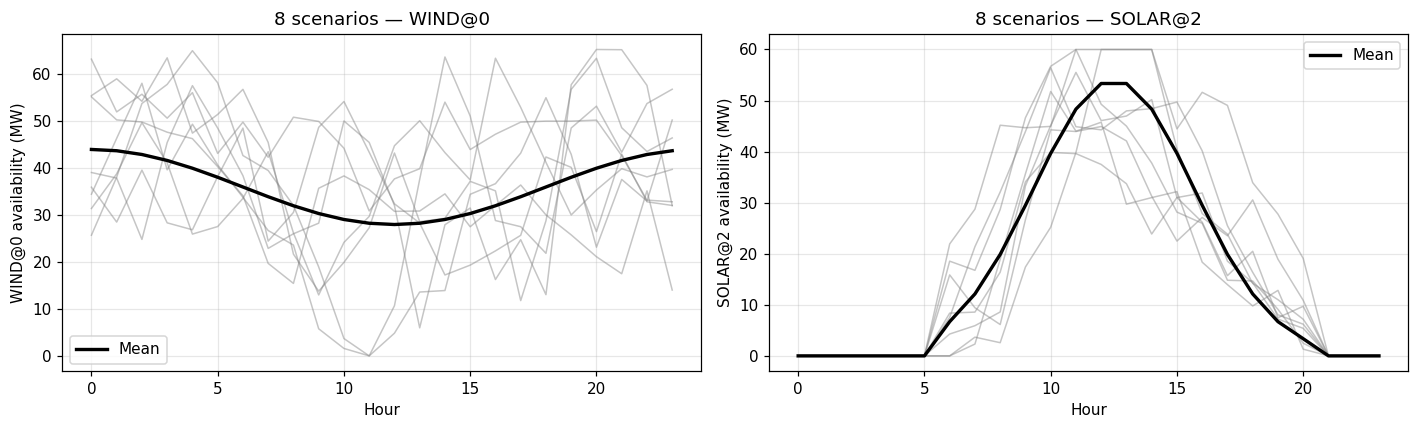

In [ ]:
asset_means = {
    'WIND@0':  wind_profile(24),
    'SOLAR@2': solar_profile(24),
}
scens = sample_scenarios(asset_means, n_scenarios=8, sigma=0.18, seed=11)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
viz.plot_scenarios(scens, 'WIND@0',  capacity_mw=80,
                   mean_profile=asset_means['WIND@0'], ax=axes[0])
viz.plot_scenarios(scens, 'SOLAR@2', capacity_mw=60,
                   mean_profile=asset_means['SOLAR@2'], ax=axes[1])
plt.tight_layout(); plt.show()

## 6 · UC stochastique à deux étapes

**Le problème décisionnel :** le gestionnaire du réseau doit décider *la veille au soir* quelles centrales thermiques seront disponibles demain — **avant de connaître** la production solaire/éolienne réelle.

Si les renouvelables produisent moins que prévu, il faut avoir des centrales thermiques disponibles pour compenser. Si elles produisent plus, on risque de devoir écrêter (jeter de l'énergie renouvelable).

**La solution : optimisation stochastique à deux étapes**

| Étape | Moment | Décisions | Variables CP-SAT |
|-------|--------|-----------|-----------------|
| **1re étape** (here-and-now) | Avant d'observer les renouvelables | Engagement des centrales thermiques | `u[g,t]`, `su[g,t]`, `sd[g,t]` — **identiques pour tous les scénarios** |
| **2e étape** (wait-and-see) | Après observation, un jeu par scénario | Puissance produite, délestage éventuel | `p[g,t,s]`, `ls[b,t,s]`, `curt[g,t,s]` |

**Pénalités de 2e étape :**

| Événement | Pénalité | Signification |
|-----------|----------|---------------|
| Délestage (load shedding) | 5 000 $/MWh | Coupure de courant — inacceptable |
| Écrêtage (curtailment) | 50 $/MWh | On "jette" de la production renouvelable |

L'objectif minimise le **coût espéré** pondéré par les probabilités des scénarios.

In [ ]:
net_r = add_renewables(three_bus_toy(peak_load=300),
                       wind_bus=0, solar_bus=2,
                       wind_cap=80, solar_cap=60)
asset_means = {'WIND@0':  wind_profile(24),
               'SOLAR@2': solar_profile(24)}
scens = sample_scenarios(asset_means, n_scenarios=4, sigma=0.15, seed=42)

sto = solve_stochastic_uc(net_r, load, scens, time_limit_s=60)
print(sto.report())

Status            : FEASIBLE
Horizon × Scen.   : 24 × 4
Expected cost     : $115,917.98
  fuel (expected) : $115,367.98
  commitment      : $550.00
  curtailed (avg) : 0.0 MWh (50 $/MWh penalty)
  unserved  (avg) : 0.00 MWh (5000 $/MWh penalty)
Wall time         : 60.02 s

First-stage commitment (same for every scenario):
Gen            0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18  19  20  21  22  23
  G1-base      1   1   1   1   1   1   1   1   1   1   1   1   1   1   1   1   1   1   1   1   1   1   1   1
  G2-mid       1   0   0   0   0   0   0   0   0   0   0   0   0   0   1   1   1   1   1   1   1   1   1   1
  G3-peaker    1   1   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   1   1   1   1   0   0
  WIND@0       1   1   1   1   1   1   1   1   1   1   1   1   1   1   1   1   1   1   1   1   1   1   1   1
  SOLAR@2      1   1   1   1   1   1   1   1   1   1   1   1   1   1   1   1   1   1   1   1   1   1   1   1


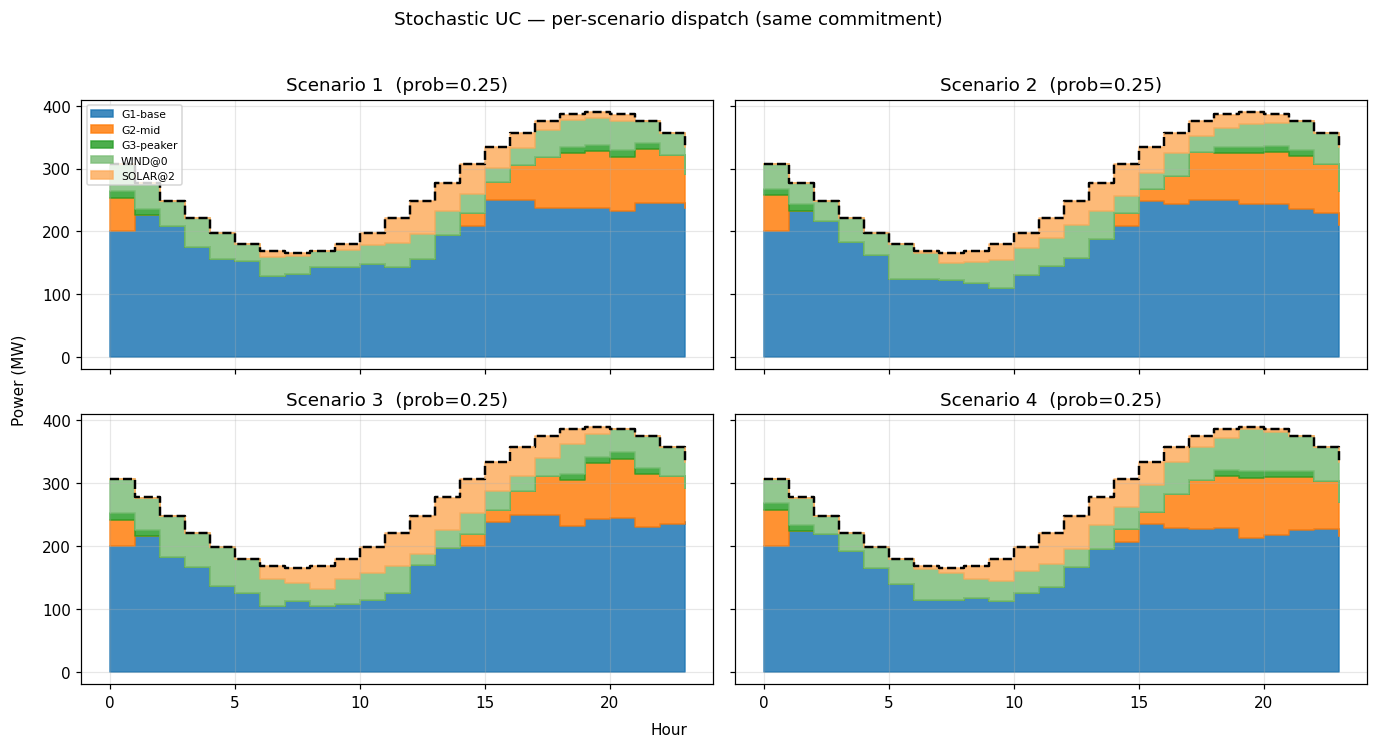

In [ ]:
# Plot per-scenario dispatch (each scenario as a small subplot)
fig, axes = plt.subplots(2, 2, figsize=(13, 7), sharex=True, sharey=True)
import numpy as np
xs = np.arange(sto.horizon)
for s, ax in enumerate(axes.flat):
    bottom = np.zeros(sto.horizon)
    for i, g in enumerate(net_r.generators):
        ys = np.array(sto.power[g.id][s])
        ax.fill_between(xs, bottom, bottom + ys,
                        color=viz._gen_color(net_r, g.id, i), alpha=0.85,
                        step='post', label=g.id if s == 0 else None)
        bottom += ys
    ax.step(xs, [sum(r) for r in load], where='post',
            color='black', linewidth=1.6, linestyle='--')
    ax.set_title(f'Scenario {s+1}  (prob={sto.probabilities[s]:.2f})')
    ax.grid(alpha=0.3)
axes[0,0].legend(fontsize=7, loc='upper left')
fig.text(0.5, 0.04, 'Hour', ha='center'); fig.text(0.04, 0.5, 'Power (MW)',
        va='center', rotation='vertical')
fig.suptitle('Stochastic UC — per-scenario dispatch (same commitment)')
plt.tight_layout(rect=[0.05, 0.05, 1, 0.96]); plt.show()

## 7 · VSS — la valeur de modéliser l'incertitude

**La question :** est-ce que ça vaut vraiment la peine de modéliser explicitement l'incertitude ? Ne suffit-il pas d'utiliser la prévision moyenne ?

On compare deux stratégies :

**Problème à valeur moyenne (MVP)** — stratégie naïve
On résout un UC déterministe en supposant que les renouvelables produiront exactement leur valeur moyenne. Simple, rapide, mais potentiellement sous-optimal.

**UC stochastique** — stratégie robuste
On résout en tenant compte de tous les scénarios possibles et de leurs probabilités. Plus complexe, mais meilleure couverture des risques.

**La VSS (Value of Stochastic Solution) :**
```
VSS = Coût(MVP) - Coût(stochastique espéré)
```

- **VSS > 0** : l'approche stochastique est moins chère en espérance — l'incertitude coûte cher si on l'ignore
- **VSS ≤ 0** : les deux approches sont équivalentes sur cette instance — le réseau est assez flexible pour absorber l'incertitude naturellement

> Sur cet exemple, le signe du delta dépend du niveau de pénétration renouvelable et de la flexibilité des centrales thermiques disponibles.

In [ ]:
# Mean-value problem: run a deterministic UC with renewables at their mean availability
det_avail = {gid: [cf * (80 if 'WIND' in gid else 60) for cf in cfs]
             for gid, cfs in asset_means.items()}
det_uc = solve_unit_commitment(net_r, load, availability=det_avail, time_limit_s=40)
print(f'Mean-value-problem UC cost           : ${det_uc.total_cost:,.2f}')
print(f'Stochastic UC (expected cost, 4 scen): ${sto.expected_cost:,.2f}')
delta = sto.expected_cost - det_uc.total_cost
print(f'Δ                                    : ${delta:+,.2f}'
      f'   ({"VSS-positive" if delta > 0 else "≤ MVP — uncertainty cheap on this instance"})')

Mean-value-problem UC cost           : $117,693.64
Stochastic UC (expected cost, 4 scen): $115,917.98
Δ                                    : $-1,775.66   (≤ MVP — uncertainty cheap on this instance)


## 8 · Benchmark de scalabilité

On mesure le temps de résolution sur les trois instances disponibles pour valider que CP-SAT reste utilisable quand le réseau grandit.

Les trois instances ont des caractéristiques très différentes (nombre de bus, de lignes, de générateurs), ce qui permet de voir comment le temps de calcul évolue.

In [ ]:
import time
print(f'{"instance":<22}{"buses":>7}{"gens":>6}{"load(MW)":>11}'
      f'{"cost($/h)":>12}{"time(s)":>10}{"status":>11}')
for net in (three_bus_toy(300), six_bus_congested(), ieee14()):
    t0 = time.time()
    s = solve_economic_dispatch(net, time_limit_s=30)
    dt = time.time() - t0
    print(f'{net.name:<22}{len(net.buses):>7}{len(net.generators):>6}'
          f'{net.total_load():>11.0f}{s.total_cost:>12,.0f}'
          f'{dt:>10.2f}{s.status:>11}')

instance                buses  gens   load(MW)   cost($/h)   time(s)     status
3-bus-toy                   3     3        300       6,519      0.01    OPTIMAL
6-bus-congested             6     4        340      11,714      0.00    OPTIMAL


IEEE-14                    14     5        259       5,912      0.45    OPTIMAL


## 9 · Pour aller plus loin

Le package `src/` expose plusieurs fonctionnalités non utilisées dans ce notebook. Voici comment les activer.

---

**Construire votre propre réseau**

```python
from src.instance import Bus, Line, Generator, PowerNetwork, GenKind

buses = [Bus(0, "Nord", load=0), Bus(1, "Sud", load=200)]
lines = [Line(0, 1, capacity=150)]
gens  = [Generator(id="G1", bus=0, p_min=30, p_max=200,
                   cost_a=100, cost_b=20, cost_c=0.005,
                   startup_cost=200, shutdown_cost=50,
                   min_up=3, min_down=2, ramp_up=80, ramp_down=80,
                   init_state=1, init_power=100, kind=GenKind.THERMAL)]
net = PowerNetwork(buses, lines, gens, name="mon-reseau")
```

---

**Paramètres avancés des solveurs**

| Paramètre | Fonction | Valeur par défaut |
|-----------|----------|-------------------|
| `time_limit_s` | Temps maximum accordé au solveur (secondes) | 30 (ED), 40 (UC), 60 (SUC) |
| `workers` | Threads CP-SAT en parallèle | auto |
| `log_search` | Afficher les logs détaillés du solveur | False |
| `reserve_profile` | Réserve tournante variable dans le temps (MW/heure) | fraction fixe |
| `availability` | Profil de disponibilité renouvelable personnalisé | 1.0 partout |

---

**Idées d'extension**
- Horizon plus long : passez `H=48` pour planifier deux jours
- Marchés d'énergie : ajoutez des contraintes de prix (offres/demandes)
- Stockage batterie : modélisez une batterie comme un générateur avec puissance négative (charge)
- Réseau DC complet : remplacez le modèle de transport par des équations de flux AC linéarisées (DC-OPF)

---

📖 Formulation mathématique complète : [`README.md`](../README.md)
📁 Description de chaque fichier source : [`DOCUMENTATION.md`](../DOCUMENTATION.md)